# Start coding and Enjoy the journey

## Install the repo

In [1]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
!pip install wandb

import wandb
wandb.login(key="")

run=wandb.init(
    entity="bea-gn03-politecnico-di-torino",
    project="Progetto_VPR",
    # name="esperimento-1" # Opzionale: scommenta questa riga per dare un nome specifico alla singola run
)

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


In [ ]:
!git clone --recursive https://github.com/androsida/Visual-Place-Recognition-Project

Cloning into 'Visual-Place-Recognition-Project'...
remote: Enumerating objects: 212, done.
remote: Counting objects: 100% (212/212), done.
remote: Compressing objects: 100% (206/206), done.
remote: Total 212 (delta 77), reused 98 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (212/212), 1.41 MiB | 37.08 MiB/s, done.
Resolving deltas: 100% (77/77), done.
Submodule 'image-matching-models' (https://github.com/alexstoken/image-matching-models.git) registered for path 'image-matching-models'
Cloning into '/content/Visual-Place-Recognition-Project/image-matching-models'...
remote: Enumerating objects: 2633, done.        
remote: Counting objects: 100% (1020/1020), done.        
remote: Compressing objects: 100% (315/315), done.        
remote: Total 2633 (delta 796), reused 717 (delta 705), pack-reused 1613 (from 3)        
Receiving objects: 100% (2633/2633), 103.55 MiB | 19.34 MiB/s, done.
Resolving deltas: 100% (1837/1837), done.
Submodule path 'image-matching-models': checked 

## Install dependencies

In [ ]:
%cd '/content/Visual-Place-Recognition-Project/image-matching-models'
!pip install -e .[all]

/content/Visual-Place-Recognition-Project/image-matching-models
Obtaining file:///content/Visual-Place-Recognition-Project/image-matching-models
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 8.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.3/225.3 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 6

In [ ]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 70.8 MB/s eta 0:00:00


## Download Datasets

In [ ]:
%cd /content/Visual-Place-Recognition-Project

!python download_datasets.py

/content/Visual-Place-Recognition-Project
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gdown/download.py", line 273, in download
    url = get_url_from_gdrive_confirmation(res.text)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gdown/download.py", line 53, in get_url_from_gdrive_confirmation
    raise FileURLRetrievalError(error)
gdown.exceptions.FileURLRetrievalError: Too many users have viewed or downloaded this file recently. Please try accessing the file again later. If the file you are trying to access is particularly large or is shared with many people, it may take up to 24 hours to be able to view or download the file. If you still can't access a file after 24 hours, contact your domain administrator.

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/content/Visual-Place-Recognition-Project/download_datasets.py", line 16, in

In [ ]:
# da usare se non si riesce a fare il download

%cd /content/Visual-Place-Recognition-Project

!mkdir -p data

!cp "/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/database_zip/sf_xs.zip" "data/sf_xs.zip"
!cp "/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/database_zip/tokyo_xs.zip" "data/tokyo_xs.zip"
!cp "/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/database_zip/gsv_xs.zip" "data/gsv_xs.zip"
!cp "/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/database_zip/svox.zip" "data/svox.zip"


!unzip -q data/sf_xs.zip -d data/
!unzip -q data/tokyo_xs.zip -d data/
!unzip -q data/gsv_xs.zip -d data/
!unzip -q data/svox.zip -d data/


!rm data/sf_xs.zip
!rm data/tokyo_xs.zip
!rm data/gsv_xs.zip
!rm data/svox.zip

/content/Visual-Place-Recognition-Project


## Run your First VPR Evalutation



In [ ]:
!python VPR-methods-evaluation/main.py \
--num_workers 8 \
--batch_size 32 \
--log_dir '/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Image_Matching_methods/mixvpr' \
--method=mixvpr \
--backbone=ResNet50 \
--descriptors_dimension=4096 \
--distance_metric="l2" \
--image_size 320 320 \
--database_folder '/content/Visual-Place-Recognition-Project/data/svox/images/test/gallery' \
--queries_folder '/content/Visual-Place-Recognition-Project/data/svox/images/test/queries_night' \
--num_preds_to_save 20 \
--recall_values 1 5 10 20 \
--save_for_uncertainty

2026-05-08 16:11:17 VPR-methods-evaluation/main.py --num_workers 8 --batch_size 32 --log_dir /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Image_Matching_methods/mixvpr --method=mixvpr --backbone=ResNet50 --descriptors_dimension=4096 --distance_metric=l2 --image_size 320 320 --database_folder /content/Visual-Place-Recognition-Project/data/svox/images/test/gallery --queries_folder /content/Visual-Place-Recognition-Project/data/svox/images/test/queries_night --num_preds_to_save 20 --recall_values 1 5 10 20 --save_for_uncertainty
2026-05-08 16:11:17 Arguments: Namespace(positive_dist_threshold=25, method='mixvpr', backbone='ResNet50', distance_metric='l2', descriptors_dimension=4096, database_folder='/content/Visual-Place-Recognition-Project/data/svox/images/test/gallery', queries_folder='/content/Visual-Place-Recognition-Project/data/svox/images/test/queries_night', num_workers=8, batch_size=32, log_dir='/content/drive/MyDrive/Progetto_VPR/Visual-Place-Reco

## Run Image Matching on Retrieval Results



In [ ]:
!python match_queries_preds.py \
--preds-dir '<path-to-predictions-folder>' \
--matcher 'superpoint-lg' \
--device 'cuda' \
--num-preds 20

## Check Re-ranking Performance

In [ ]:
!python reranking.py \
--preds-dir '<path-to-predictions-folder>' \
--inliers-dir '<path-to-inliers-folder>' \
--num-preds 20 \
--recall-values 1 5 10 20

## Perform Uncertainty Evalutation

In [ ]:
!python -m vpr_uncertainty.eval \
--preds-dir '<path-to-predictions-folder>' \
--inliers-dir '<path-to-inliers-folder>' \
--z-data-path '<path-to-z-data-file>'

# CALCOLO DEL TEMPO

ricavo del tempo di Image Matching dai fiel .torch

In [ ]:
from pathlib import Path
from datetime import datetime
import numpy as np

# Cambia questo path
folder = Path("/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Image_Matching_methods/mixvpr/svox/night/preds_loftr")

# Prende tutti i .torch
files = list(folder.glob("*.torch"))

if len(files) == 0:
    raise ValueError(f"Nessun file .torch trovato in {folder}")

# Ordina per timestamp di modifica
files = sorted(files, key=lambda p: p.stat().st_mtime)

# Timestamp in secondi
times = np.array([p.stat().st_mtime for p in files])

first_file = files[0]
last_file = files[-1]

first_time = times[0]
last_time = times[-1]

total_time = last_time - first_time

# Se usiamo primo e ultimo file, gli intervalli sono n_file - 1
avg_time_per_query = total_time / (len(files) - 1) if len(files) > 1 else 0.0

log_text = f"""Cartella: {folder}
Numero file .torch: {len(files)}

Primo file generato:
{first_file.name} - {datetime.fromtimestamp(first_time)}

Ultimo file generato:
{last_file.name} - {datetime.fromtimestamp(last_time)}

Tempo totale stimato:
{total_time:.2f} s
{total_time / 60:.2f} min

Tempo medio stimato per query:
{avg_time_per_query:.6f} s/query
"""

print(log_text)

# Nome file log con timestamp
log_file = folder / f"log_tempo_query.txt"

# Salvataggio
log_file.write_text(log_text, encoding="utf-8")

print(f"Log salvato in:\n{log_file}")

Cartella: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Image_Matching_methods/mixvpr/svox/night/preds_loftr
Numero file .torch: 823

Primo file generato:
000.torch - 2026-05-04 19:04:58

Ultimo file generato:
822.torch - 2026-05-04 19:59:16

Tempo totale stimato:
3258.00 s
54.30 min

Tempo medio stimato per query:
3.963504 s/query

Log salvato in:
/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Image_Matching_methods/mixvpr/svox/night/preds_loftr/log_tempo_query.txt


per calcolare il tempo totale

In [ ]:
import re
from pathlib import Path

%cd /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/
# 1. IMPOSTAZIONI
datasets = ['sf_xs', 'tokyo_xs', 'svox/sun', 'svox/night']
methods = ['superglue', 'loftr', 'superpoint-lg']
base_dir = Path("/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Image_Matching_methods/cosplace")

csv_file = base_dir / "tabella_finale_tempi_query.csv"
csv_lines = ["Dataset,Metodo,Global_Mean_s,Matching_Mean_s,Reranking_Mean_s,Totale_Query_ms\n"]

# 2. REGEX (Catturano i numeri dopo le frasi chiave)
global_avg_pattern = re.compile(r"Single \(mean\) query processing time:[^\d]*(\d+(?:\.\d+)?)", re.IGNORECASE)
match_avg_pattern = re.compile(r"Tempo medio[^\d]*per query:[^\d]*(\d+(?:\.\d+)?)", re.IGNORECASE)
rerank_avg_pattern = re.compile(r"Reranking time per query:[^\d]*(\d+(?:\.\d+)?)", re.IGNORECASE)

print(f"{'DATASET':<12} | {'METODO':<15} | {'TOTALE ms/query':<15}")
print("-" * 50)

# 3. CICLO DI ESTRAZIONE
for ds in datasets:
    dataset_dir = base_dir / ds
    if not dataset_dir.exists(): continue

    # --- A. GLOBAL MEAN ---
    global_avg = 0.0
    # Cerchiamo info.log con asterisco per beccare anche info (1).log o .txt
    log_candidates = list(dataset_dir.rglob("info*log*")) + list(dataset_dir.rglob("info*txt*"))
    if not log_candidates:
        log_candidates = list(dataset_dir.parent.glob("info*log*"))

    if log_candidates:
        latest_log = max(log_candidates, key=lambda f: f.stat().st_mtime)
        with open(latest_log, 'r', encoding='utf-8', errors='ignore') as f:
            m = global_avg_pattern.search(f.read())
            if m: global_avg = float(m.group(1))

    # --- B. MATCHING & RERANKING ---
    for method in methods:
        match_avg, rerank_avg = 0.0, 0.0

        # Matching
        preds_dir = dataset_dir / f"preds_{method}"
        log_match = list(preds_dir.glob("log_tempo_query*"))
        if log_match:
            with open(log_match[0], 'r', encoding='utf-8', errors='ignore') as f:
                m = match_avg_pattern.search(f.read())
                if m: match_avg = float(m.group(1))

        # Reranking
        rerank_files = list(dataset_dir.glob(f"results_reranking_{method}*"))

        if rerank_files:
        # Trova il file modificato più recentemente tra quelli che corrispondono
          latest_rr = max(rerank_files, key=lambda f: f.stat().st_mtime)

          with open(latest_rr, 'r', encoding='utf-8', errors='ignore') as f:
            content = f.read()
            m = rerank_avg_pattern.search(content)
            if m:
              rerank_avg = float(m.group(1))


        # Calcolo Totale in millisecondi
        totale_ms = (global_avg + match_avg + rerank_avg) * 1000

        # Stampa riga tabella a schermo
        print(f"{ds:<12} | {method:<15} | {totale_ms:>8.2f} ms")

        # Aggiungi riga per CSV
        csv_lines.append(f"{ds},{method},{global_avg:.6f},{match_avg:.6f},{rerank_avg:.6f},{totale_ms:.2f}\n")

# 4. SALVATAGGIO
csv_file.write_text("".join(csv_lines))
print("-" * 50)
print(f"\n✅ Tabella salvata in: {csv_file}")

/content/drive/.shortcut-targets-by-id/1RF24y3xBH8DLu-NcbhGNL4sTO05Wsxn_/Progetto_VPR/Visual-Place-Recognition-Project
DATASET      | METODO          | TOTALE ms/query
--------------------------------------------------
sf_xs        | superglue       |  2352.59 ms
sf_xs        | loftr           |  4588.17 ms
sf_xs        | superpoint-lg   |  4492.00 ms
tokyo_xs     | superglue       |  2433.15 ms
tokyo_xs     | loftr           |  4994.96 ms
tokyo_xs     | superpoint-lg   |  4824.16 ms
svox/sun     | superglue       |  2459.54 ms
svox/sun     | loftr           |  4985.67 ms
svox/sun     | superpoint-lg   |  4801.40 ms
svox/night   | superglue       |  2373.27 ms
svox/night   | loftr           |  5022.30 ms
svox/night   | superpoint-lg   |  4960.82 ms
--------------------------------------------------

✅ Tabella salvata in: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Image_Matching_methods/cosplace/tabella_finale_tempi_query.csv


# ESERCIZIO 5.3

##estrazione inliers (Esegui solo se non hai già salvato su Drive il dataframe con gli inliers estratti)

In [ ]:
import torch
import os
import pandas as pd
from glob import glob
from pathlib import Path
from tqdm import tqdm

%cd /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/

# 1. Configurazione Iniziale

# NB CAMBIA QUI IL METODO!

vpr_method = "cosplace"

datasets = ['tokyo_xs', "sf_xs", "svox/sun", "svox/night"]
methods = ['superglue', 'loftr', 'superpoint-lg']
base_dir = '/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results'

tutti_i_dati = []

# 2. Ciclo di Estrazione Universale
for dataset in datasets:
    for method in methods:

        preds_dir = os.path.join(base_dir, 'Image_Matching_methods', vpr_method, dataset, 'preds')
        inliers_dir = os.path.join(base_dir, 'Image_Matching_methods', vpr_method, dataset, f'preds_{method}')

        if not os.path.exists(inliers_dir) or not os.path.exists(preds_dir):
            continue

        torch_files = glob(os.path.join(inliers_dir, "*.torch"))

        for torch_path in tqdm(torch_files, desc=f"Estrazione {dataset}/{method}", leave=False):
            q_name = Path(torch_path).stem
            txt_path = os.path.join(preds_dir, f"{q_name}.txt")

            if not os.path.exists(txt_path):
                continue

            # Lettura Inliers
            try:
                data = torch.load(torch_path, map_location="cpu", weights_only=False)
                if not data: continue

                # Estraiamo tutta la lista degli inliers per questa query
                if isinstance(data, list) and isinstance(data[0], dict) and 'num_inliers' in data[0]:
                    inliers_list = [item['num_inliers'] for item in data]
                elif isinstance(data, dict) and 'num_inliers' in data:
                    inliers_list = [data['num_inliers']]
                else:
                    continue
            except Exception:
                continue

            # Lettura correttezza (Positivi)
            try:
                with open(txt_path, 'r') as f:
                    content = f.read().splitlines()

                preds_start = content.index("Predictions paths:") + 1
                positives_start = content.index("Positives paths:") + 1

                predictions = [Path(line.strip()).name for line in content[preds_start:positives_start-1] if line.strip()]
                positives = {Path(line.strip()).name for line in content[positives_start:] if line.strip()}

                if not predictions or not positives:
                    continue

            except (ValueError, IndexError):
                continue

            # Calcolo metriche per la riga
            k = min(len(predictions), len(inliers_list))
            if k == 0: continue

            base_correct = predictions[0] in positives

            # Troviamo l'indice del candidato con più inliers per il full_reranking
            best_idx = max(range(k), key=lambda i: (inliers_list[i], -i))
            full_correct = predictions[best_idx] in positives

            # Aggiungiamo la riga al "database"
            tutti_i_dati.append({
                "dataset": dataset,
                "method": method,
                "query": q_name,
                "rank1_inliers": inliers_list[0],
                "base_correct": base_correct,
                "full_correct": full_correct,
                "k": k
            })

# 3. Creazione del DataFrame globale in memoria
df_risultati = pd.DataFrame(tutti_i_dati)
# 4. Salvataggio direttamente nella cartella drive del metodo VPR del csv e del .pkl
output_dir = Path(base_dir) / "Image_Matching_methods" / vpr_method
output_dir.mkdir(parents=True, exist_ok=True)

pkl_path = output_dir / f"df_risultati_adaptive_{vpr_method}.pkl"
csv_path = output_dir / f"df_risultati_adaptive_{vpr_method}.csv"

df_risultati.to_pickle(pkl_path)
df_risultati.to_csv(csv_path, index=False)


print(f".pkl salvato in: {pkl_path}")
print(f"CSV salvato in: {csv_path}")
print(f"\n Estrazione completata! Tabella creata con {len(df_risultati)} query totali.")

df_risultati.head()

/content/drive/.shortcut-targets-by-id/1RF24y3xBH8DLu-NcbhGNL4sTO05Wsxn_/Progetto_VPR/Visual-Place-Recognition-Project



✅ Estrazione completata! Tabella creata con 8874 query totali.


,dataset,method,query,rank1_inliers,base_correct,full_correct,k
0,tokyo_xs,superglue,000,7,True,True,20
1,tokyo_xs,superglue,001,6,False,False,20
2,tokyo_xs,superglue,002,4,False,False,20
3,tokyo_xs,superglue,003,20,False,True,20
4,tokyo_xs,superglue,004,26,True,True,20


**Caricamento del dataframe (se presente .pkl) direttamente da drive (evita di rifare il lungo parsing di .torch e .txt sul drive)**

In [5]:
import torch
import os
import pandas as pd
from glob import glob
from pathlib import Path

vpr_method = "cosplace"

datasets = ['tokyo_xs', "sf_xs", "svox/sun", "svox/night"]
methods = ['superglue', 'loftr', 'superpoint-lg']

base_dir = Path("/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results")

pkl_path = (
    base_dir
    / "Image_Matching_methods"
    / vpr_method
    / f"df_risultati_adaptive_{vpr_method}.pkl"
)

df_risultati = pd.read_pickle(pkl_path)

print(f"DataFrame caricato: {len(df_risultati)} righe")
df_risultati.head()

DataFrame caricato: 8874 righe


,dataset,method,query,rank1_inliers,base_correct,full_correct,k
0,tokyo_xs,superglue,000,7,True,True,20
1,tokyo_xs,superglue,001,6,False,False,20
2,tokyo_xs,superglue,002,4,False,False,20
3,tokyo_xs,superglue,003,20,False,True,20
4,tokyo_xs,superglue,004,26,True,True,20


## creazione istogrammi

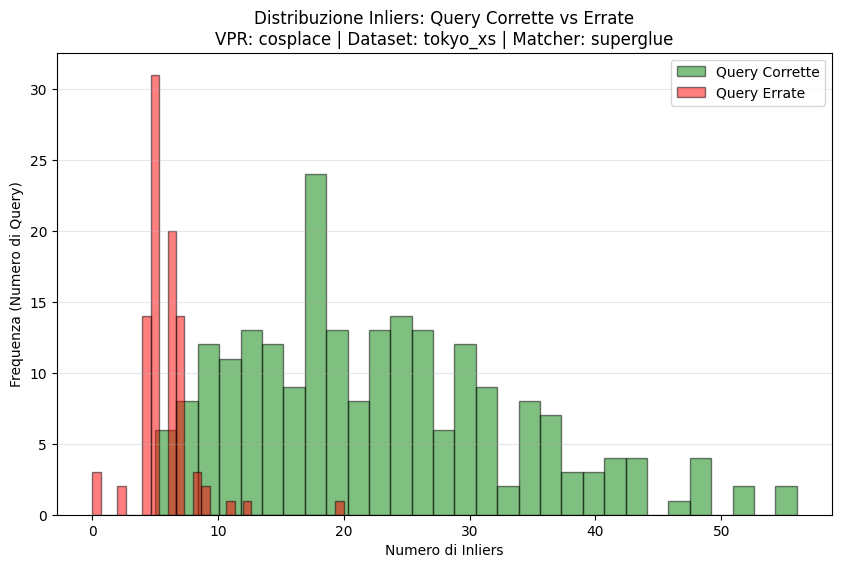

✅ Salvato: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Inliers/cosplace/tokyo_xs/istogramma_inliers_superglue.png


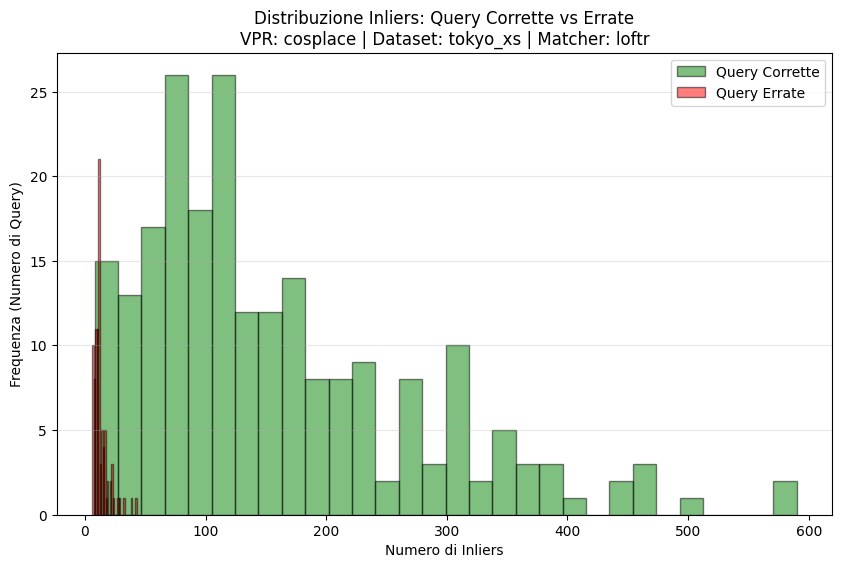

✅ Salvato: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Inliers/cosplace/tokyo_xs/istogramma_inliers_loftr.png


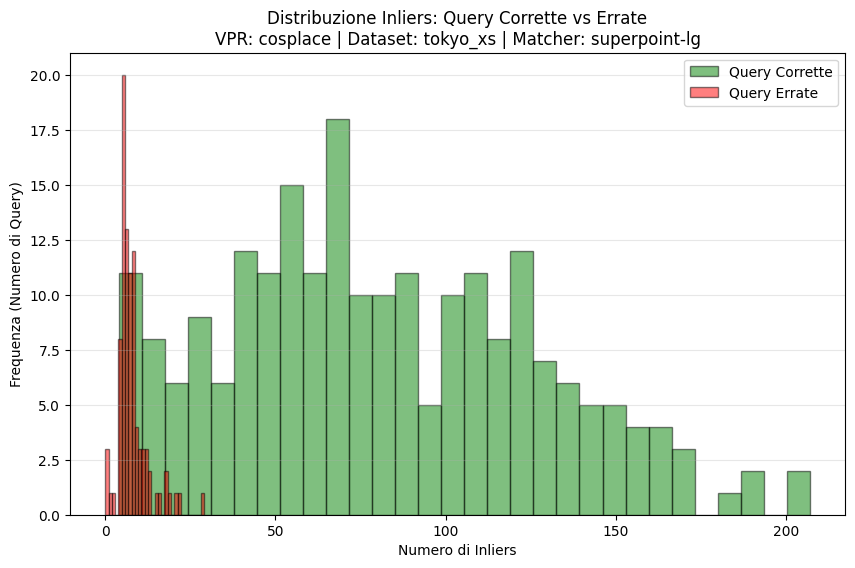

✅ Salvato: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Inliers/cosplace/tokyo_xs/istogramma_inliers_superpoint-lg.png


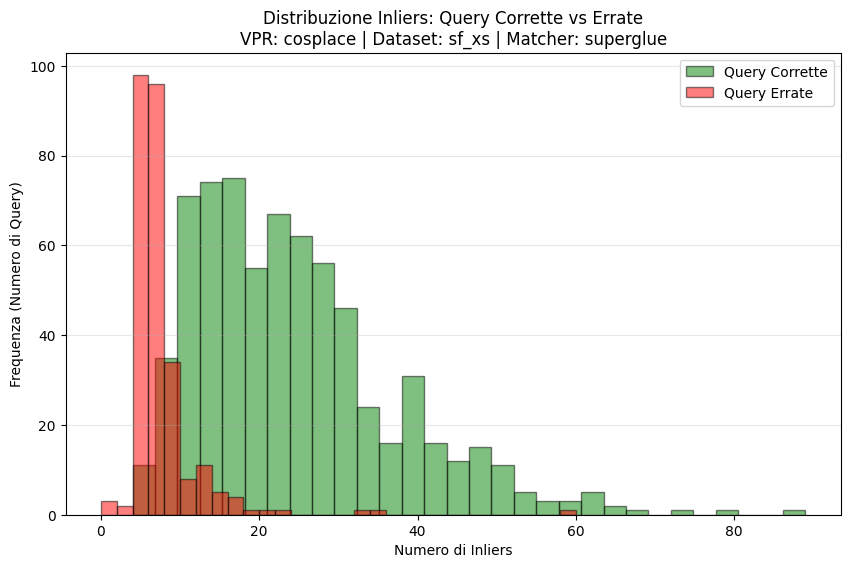

✅ Salvato: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Inliers/cosplace/sf_xs/istogramma_inliers_superglue.png


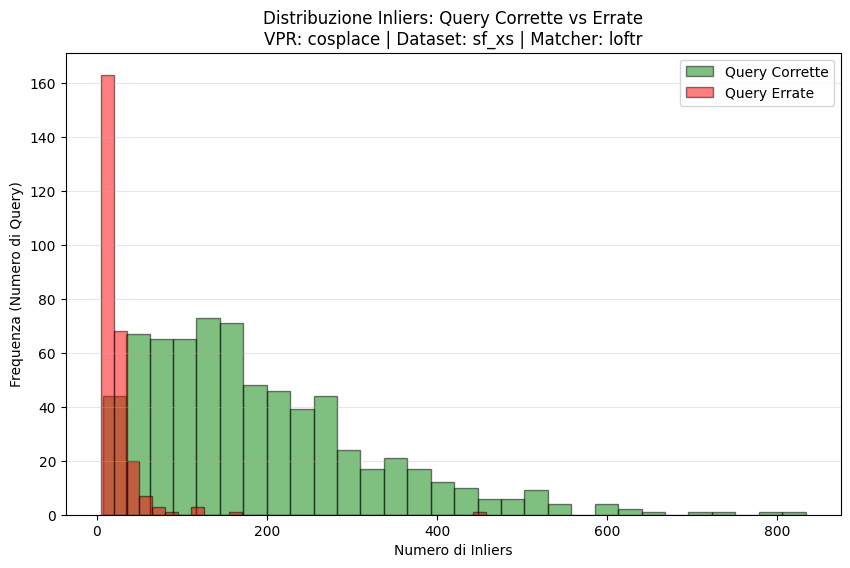

✅ Salvato: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Inliers/cosplace/sf_xs/istogramma_inliers_loftr.png


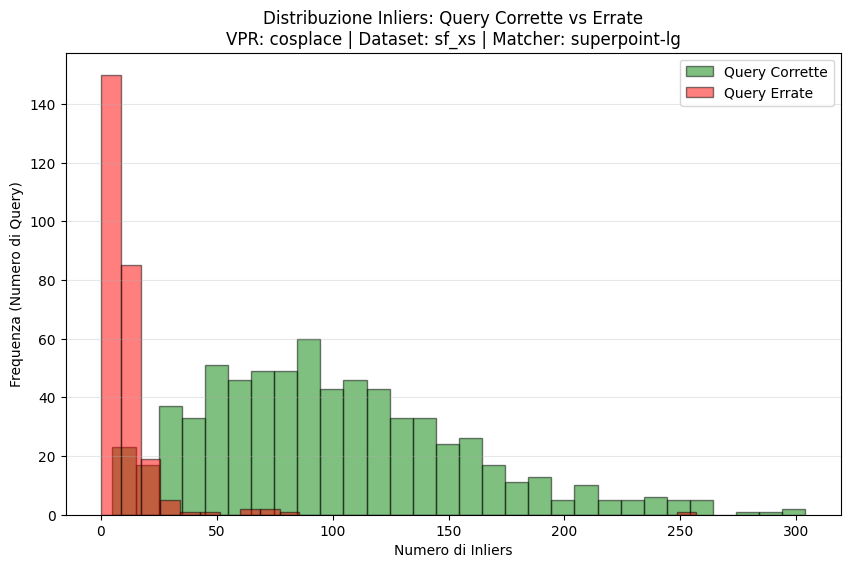

✅ Salvato: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Inliers/cosplace/sf_xs/istogramma_inliers_superpoint-lg.png


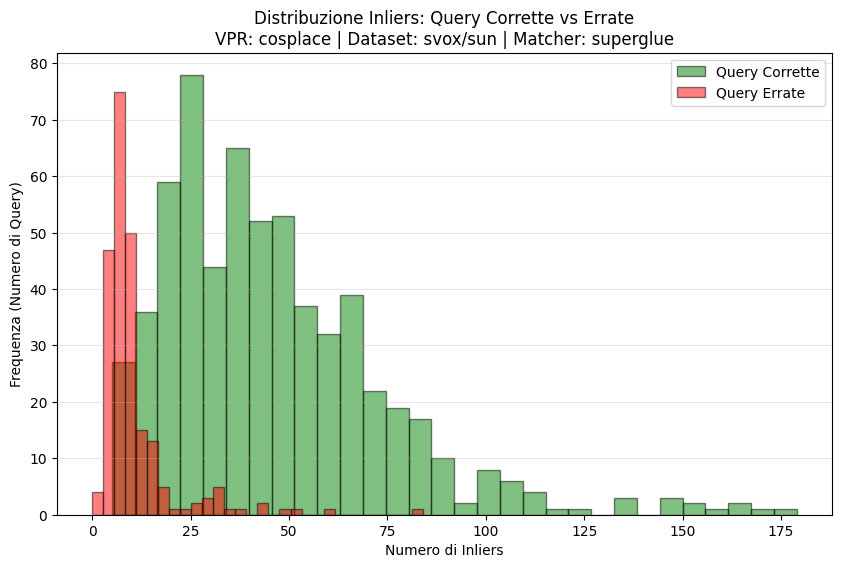

✅ Salvato: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Inliers/cosplace/svox/sun/istogramma_inliers_superglue.png


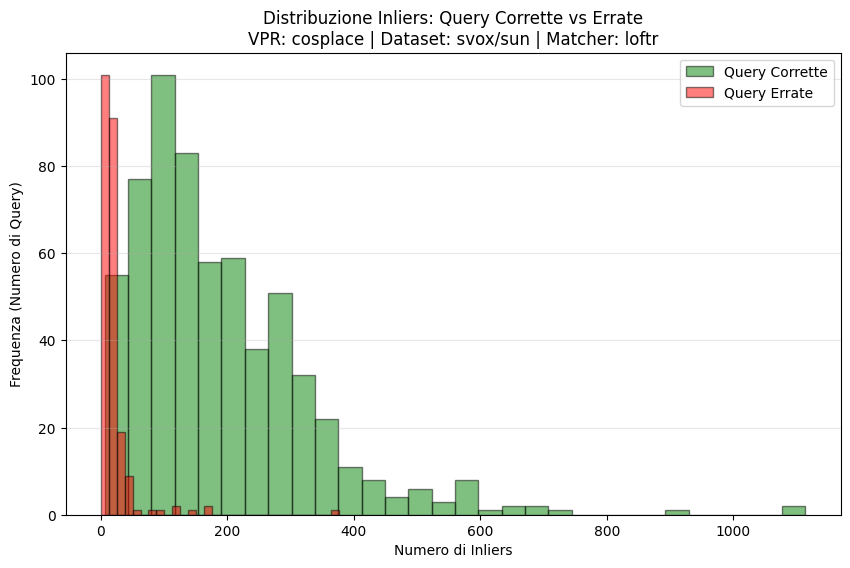

✅ Salvato: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Inliers/cosplace/svox/sun/istogramma_inliers_loftr.png


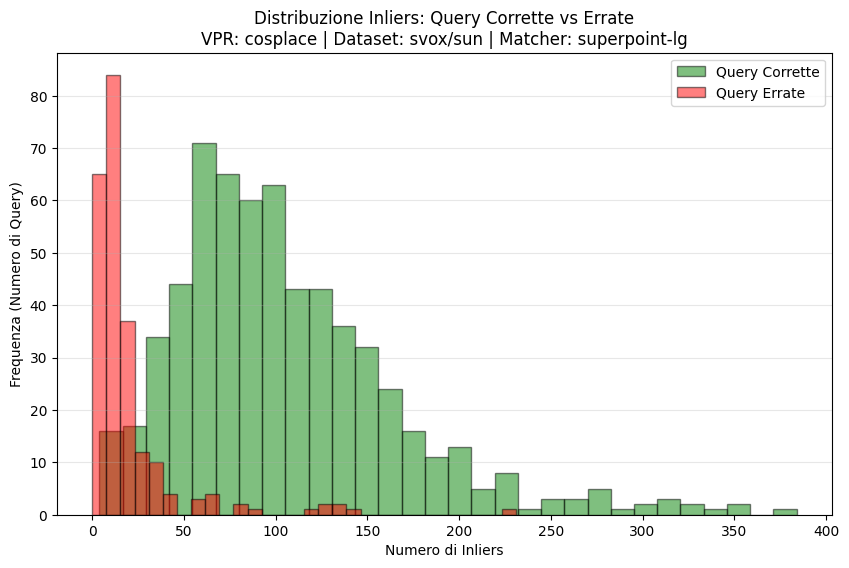

✅ Salvato: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Inliers/cosplace/svox/sun/istogramma_inliers_superpoint-lg.png


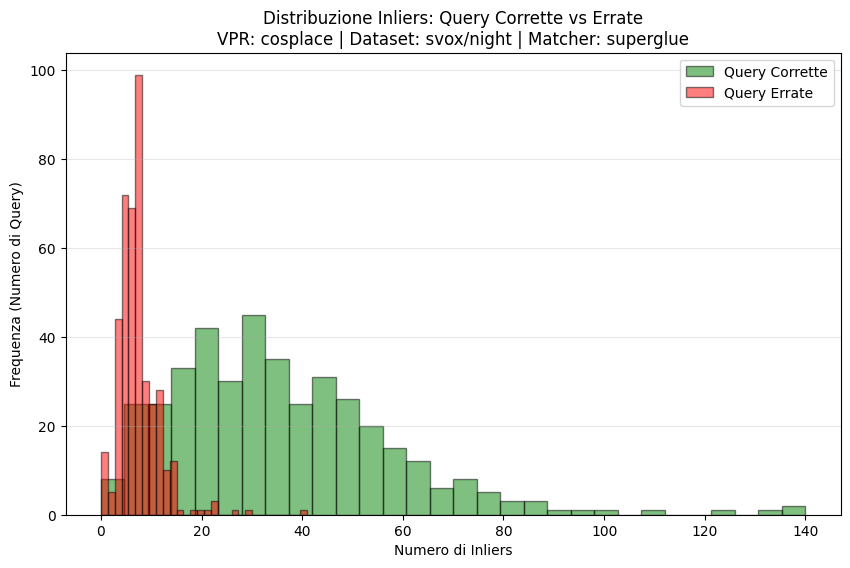

✅ Salvato: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Inliers/cosplace/svox/night/istogramma_inliers_superglue.png


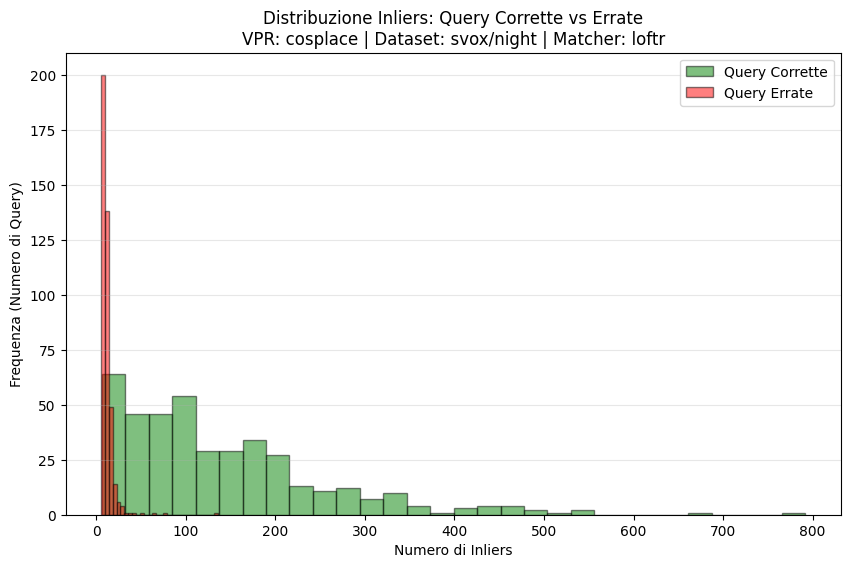

✅ Salvato: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Inliers/cosplace/svox/night/istogramma_inliers_loftr.png


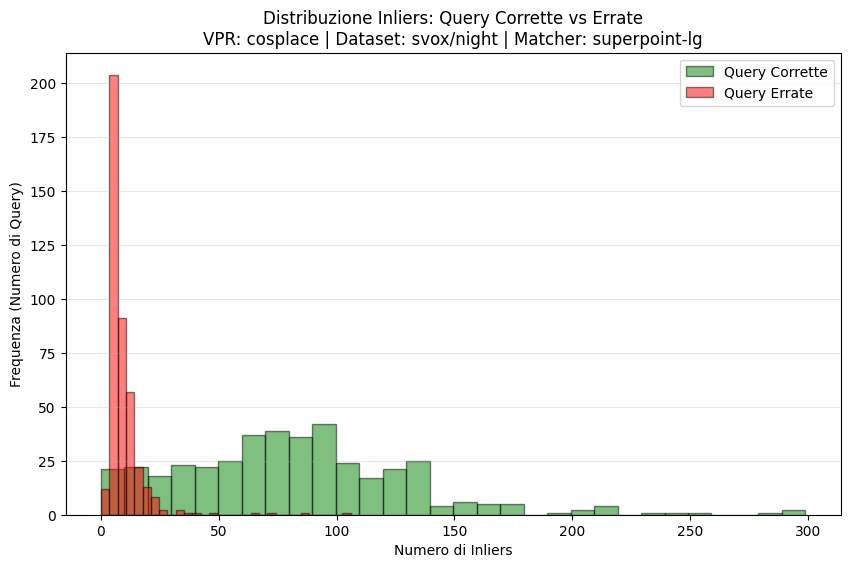

✅ Salvato: /content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Inliers/cosplace/svox/night/istogramma_inliers_superpoint-lg.png


In [8]:
import matplotlib.pyplot as plt
from pathlib import Path


# Cicliamo solo per generare i grafici
for dataset in datasets:
    for method in methods:

        # Filtriamo il database in memoria per la combinazione corrente
        df_filtrato = df_risultati[
            (df_risultati['dataset'] == dataset) &
            (df_risultati['method'] == method)
        ]

        if df_filtrato.empty:
            continue

        # Separiamo corretti e sbagliati
        correct_inliers = df_filtrato[df_filtrato['base_correct'] == True]['rank1_inliers']
        wrong_inliers = df_filtrato[df_filtrato['base_correct'] == False]['rank1_inliers']

        plt.figure(figsize=(10, 6))
        plt.hist(correct_inliers, bins=30, alpha=0.5, label='Query Corrette', color='g', edgecolor='black')
        plt.hist(wrong_inliers, bins=30, alpha=0.5, label='Query Errate', color='r', edgecolor='black')

        plt.title(
            f'Distribuzione Inliers: Query Corrette vs Errate\n'
            f'VPR: {vpr_method} | Dataset: {dataset} | Matcher: {method}'
        )
        plt.xlabel('Numero di Inliers')
        plt.ylabel('Frequenza (Numero di Query)')
        plt.legend()
        plt.grid(axis='y', alpha=0.3)

        # Salvataggio dentro la cartella Inliers
        save_dir = (
            Path(base_dir)
            / "Inliers"
            / vpr_method
            / dataset
        )

        save_dir.mkdir(parents=True, exist_ok=True)

        save_path = save_dir / f'istogramma_inliers_{method}.png'

        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()

        print(f"✅ Salvato: {save_path}")

## calcolo della soglia e tempi

In [ ]:
import torch
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm

# ============================================================
# ESPERIMENTI ADAPTIVE RERANKING + TEMPI REALI
# confronto: FULL RERANKING vs ADAPTIVE RERANKING
# ============================================================

datasets = ['sf_xs']
methods = ['superglue']

base_dir = Path("/content/drive/MyDrive/Progetto_VPR/Visual-Place-Recognition-Project/results/Image_Matching_methods/mixvpr")

soglia_csv = base_dir / "soglia_r1.csv"
tempi_csv = base_dir / "tabella_finale_tempi_query.csv"
output_csv = base_dir / "adaptive_vs_full_reranking_summary.csv"


# ------------------------------------------------------------
# UTILS
# ------------------------------------------------------------

def evaluate_adaptive_threshold(queries, threshold):
    correct = 0
    n_easy_skip = 0
    n_hard_rerank = 0
    matching_pairs_adaptive = 0
    matching_pairs_full = 0

    for q in queries:

        k = q["k"]
        matching_pairs_full += k

        if q["rank1_inliers"] >= threshold:
            # Query easy: tengo il rank-1 originale.
            matching_pairs_adaptive += 1
            n_easy_skip += 1
            correct += int(q["base_correct"])

        else:
            # Query hard: faccio full reranking.
            matching_pairs_adaptive += k
            n_hard_rerank += 1
            correct += int(q["full_correct"])

    n = len(queries)

    adaptive_r1 = 100 * correct / n if n > 0 else 0.0
    skip_pct = 100 * n_easy_skip / n if n > 0 else 0.0
    rerank_pct = 100 * n_hard_rerank / n if n > 0 else 0.0

    matching_pairs_vs_full_pct = (
        100 * matching_pairs_adaptive / matching_pairs_full
        if matching_pairs_full > 0 else 0.0
    )

    matching_pairs_saving_pct = 100 - matching_pairs_vs_full_pct

    return {
        "threshold": threshold,
        "adaptive_R@1": adaptive_r1,

        "n_easy_skip": n_easy_skip,
        "n_hard_rerank": n_hard_rerank,
        "skip_queries_%": skip_pct,
        "rerank_queries_%": rerank_pct,

        "matching_pairs_adaptive": matching_pairs_adaptive,
        "matching_pairs_full": matching_pairs_full,
        "matching_pairs_vs_full_%": matching_pairs_vs_full_pct,
        "matching_pairs_saving_%": matching_pairs_saving_pct,
    }


def get_reranking_timing(tempi_df, dataset, method):
    """
    Recupera i tempi reali dalla tabella_finale_tempi_query.csv.

    Usiamo solo:
        Matching_Mean_s
        Reranking_Mean_s

    Escludiamo:
        Global_Mean_s

    perché vogliamo confrontare solo:
        full reranking vs adaptive reranking.
    """

    row = tempi_df[
        (tempi_df["Dataset"].astype(str) == str(dataset)) &
        (tempi_df["Metodo"].astype(str) == str(method))
    ]

    if len(row) == 0:
        print(f"⚠️ Tempi non trovati per {dataset} / {method}. Uso zeri.")
        return {
            "matching_mean_s": 0.0,
            "reranking_mean_s": 0.0,
        }

    row = row.iloc[0]

    return {
        "matching_mean_s": float(row.get("Matching_Mean_s", 0.0)),
        "reranking_mean_s": float(row.get("Reranking_Mean_s", 0.0)),
    }


def add_reranking_time_estimates(res, timing, n_queries):
    """
    FULL RERANKING:
        tempo_full = tempo_matching_full + tempo_reranking_full

    ADAPTIVE RERANKING:
        tempo_adaptive =
            tempo_matching_full * frazione_matching_pairs_usati
            +
            tempo_reranking_full * frazione_query_rerankate

    Il retrieval globale NON è incluso.
    """

    matching_mean_s = timing["matching_mean_s"]
    reranking_mean_s = timing["reranking_mean_s"]

    matching_ratio = res["matching_pairs_vs_full_%"] / 100.0
    hard_query_ratio = res["rerank_queries_%"] / 100.0

    full_reranking_query_s = matching_mean_s + reranking_mean_s

    adaptive_reranking_query_s = (
        matching_mean_s * matching_ratio
        +
        reranking_mean_s * hard_query_ratio
    )

    full_reranking_total_s = n_queries * full_reranking_query_s
    adaptive_reranking_total_s = n_queries * adaptive_reranking_query_s

    delta_query_s = full_reranking_query_s - adaptive_reranking_query_s
    delta_total_s = full_reranking_total_s - adaptive_reranking_total_s

    if full_reranking_total_s > 0:
        reranking_time_saving_pct = 100 * (
            1 - adaptive_reranking_total_s / full_reranking_total_s
        )
    else:
        reranking_time_saving_pct = np.nan

    res["matching_mean_s"] = matching_mean_s
    res["reranking_mean_s"] = reranking_mean_s

    res["full_reranking_query_s"] = full_reranking_query_s
    res["adaptive_reranking_query_s"] = adaptive_reranking_query_s

    res["full_reranking_query_ms"] = full_reranking_query_s * 1000
    res["adaptive_reranking_query_ms"] = adaptive_reranking_query_s * 1000

    res["reranking_delta_query_s"] = delta_query_s
    res["reranking_delta_query_ms"] = delta_query_s * 1000

    res["full_reranking_total_s"] = full_reranking_total_s
    res["adaptive_reranking_total_s"] = adaptive_reranking_total_s

    res["full_reranking_total_min"] = full_reranking_total_s / 60
    res["adaptive_reranking_total_min"] = adaptive_reranking_total_s / 60

    res["reranking_delta_total_s"] = delta_total_s
    res["reranking_delta_total_min"] = delta_total_s / 60

    res["reranking_time_saving_%"] = reranking_time_saving_pct

    return res


# ------------------------------------------------------------
# CARICO CSV
# ------------------------------------------------------------

soglie_df = pd.read_csv(soglia_csv)
tempi_df = pd.read_csv(tempi_csv)

all_results = []


# ------------------------------------------------------------
# CICLO ESPERIMENTI
# ------------------------------------------------------------

print("Adaptive reranking: confronto full vs adaptive\n")

for _, row in soglie_df.iterrows():

    dataset = row["dataset"]
    method = row["method"]

    r1_base_log = row["r1_globale"]
    r1_full_log = row["r1_reranking"]
    soglia_recall = row["soglia_recall"]

    #queries, files_skipped = load_experiment_data(dataset, method)

    #if len(queries) == 0:
        #print(f"⚠️ {dataset:<10} | {method:<15} | nessuna query valida")
        #continue

    # --- SOSTITUZIONE ESTRAZIONE: Filtriamo df_risultati invece di leggere file ---
    df_subset = df_risultati[(df_risultati['dataset'] == dataset) & (df_risultati['method'] == method)]

    if df_subset.empty:
        print(f"⚠️ {dataset:<10} | {method:<15} | nessuna riga trovata in df_risultati")
        continue

    # Convertiamo il subset in lista di dizionari per mantenere compatibilità con le funzioni originali
    queries = df_subset.to_dict('records')
    # ------------------------------------------------------------------------------

    timing = get_reranking_timing(tempi_df, dataset, method)

    base_r1_check = 100 * np.mean([q["base_correct"] for q in queries])
    full_r1_check = 100 * np.mean([q["full_correct"] for q in queries])

    max_inliers = int(max(q["rank1_inliers"] for q in queries))

    threshold_results = []

    for threshold in range(0, max_inliers + 2):

        res = evaluate_adaptive_threshold(queries, threshold)

        res = add_reranking_time_estimates(
            res=res,
            timing=timing,
            n_queries=len(queries)
        )

        res["dataset"] = dataset
        res["method"] = method

        res["n_queries"] = len(queries)
        res["files_skipped"] = files_skipped
        res["avg_topK"] = float(np.mean([q["k"] for q in queries]))

        res["r1_base_log"] = r1_base_log
        res["r1_full_log"] = r1_full_log
        res["soglia_recall"] = soglia_recall

        res["r1_base_check"] = base_r1_check
        res["r1_full_check"] = full_r1_check

        res["loss_vs_full_check"] = full_r1_check - res["adaptive_R@1"]
        res["valid"] = res["adaptive_R@1"] >= soglia_recall

        threshold_results.append(res)

    threshold_df = pd.DataFrame(threshold_results)

    curve_path = base_dir / dataset / f"adaptive_curve_full_vs_adaptive_reranking_{method}.csv"
    threshold_df.to_csv(curve_path, index=False)

    valid_df = threshold_df[threshold_df["valid"] == True].copy()

    if len(valid_df) == 0:
        best = threshold_df.sort_values(
            by=["adaptive_R@1"],
            ascending=False
        ).iloc[0]
    else:
        best = valid_df.sort_values(
            by=[
                "adaptive_reranking_query_s",
                "matching_pairs_vs_full_%",
                "rerank_queries_%",
                "threshold"
            ],
            ascending=[True, True, True, True]
        ).iloc[0]

    all_results.append(best.to_dict())

    print(
        f"{dataset:<10} | {method:<15} | "
        f"thr={int(best['threshold']):>4} | "
        f"R@1={best['adaptive_R@1']:>6.2f}% | "
        f"full={best['full_reranking_query_ms']:>8.2f} ms/q | "
        f"adaptive={best['adaptive_reranking_query_ms']:>8.2f} ms/q | "
        f"delta={best['reranking_delta_query_ms']:>8.2f} ms/q | "
        f"saving={best['reranking_time_saving_%']:>6.2f}%"
    )


# ------------------------------------------------------------
# SUMMARY FINALE
# ------------------------------------------------------------

if len(all_results) > 0:

    results_df = pd.DataFrame(all_results)

    results_df = results_df[
        [
            "dataset",
            "method",
            "threshold",
            "adaptive_R@1",
            "soglia_recall",
            "valid",

            "r1_base_log",
            "r1_full_log",
            "r1_base_check",
            "r1_full_check",
            "loss_vs_full_check",

            "n_easy_skip",
            "n_hard_rerank",
            "skip_queries_%",
            "rerank_queries_%",

            "matching_pairs_adaptive",
            "matching_pairs_full",
            "matching_pairs_vs_full_%",
            "matching_pairs_saving_%",

            "matching_mean_s",
            "reranking_mean_s",

            "full_reranking_query_s",
            "adaptive_reranking_query_s",
            "full_reranking_query_ms",
            "adaptive_reranking_query_ms",

            "reranking_delta_query_s",
            "reranking_delta_query_ms",

            "full_reranking_total_s",
            "adaptive_reranking_total_s",
            "full_reranking_total_min",
            "adaptive_reranking_total_min",

            "reranking_delta_total_s",
            "reranking_delta_total_min",

            "reranking_time_saving_%",

            "avg_topK",
            "n_queries",
            "files_skipped",
        ]
    ]

    results_df.to_csv(output_csv, index=False)

    print("\n✅ Summary salvato in:")
    print(output_csv)

    display(results_df)

else:
    print("❌ Nessun risultato prodotto.")

Adaptive reranking: confronto full vs adaptive

sf_xs      | superglue       | thr=   7 | R@1= 78.36% | full= 1946.12 ms/q | adaptive=  384.13 ms/q | delta= 1561.99 ms/q | saving= 80.26%
sf_xs      | loftr           | thr=  24 | R@1= 78.36% | full= 4459.05 ms/q | adaptive= 1064.37 ms/q | delta= 3394.69 ms/q | saving= 76.13%
sf_xs      | superpoint-lg   | thr=  12 | R@1= 80.02% | full= 5941.97 ms/q | adaptive= 1402.42 ms/q | delta= 4539.55 ms/q | saving= 76.40%
tokyo_xs   | superglue       | thr=   7 | R@1= 86.03% | full= 2202.78 ms/q | adaptive=  488.59 ms/q | delta= 1714.19 ms/q | saving= 77.82%
tokyo_xs   | loftr           | thr=  21 | R@1= 87.62% | full= 4808.41 ms/q | adaptive= 1238.95 ms/q | delta= 3569.46 ms/q | saving= 74.23%
tokyo_xs   | superpoint-lg   | thr=  10 | R@1= 87.30% | full= 4999.58 ms/q | adaptive= 1208.77 ms/q | delta= 3790.81 ms/q | saving= 75.82%
svox/sun   | superglue       | thr=  17 | R@1= 89.46% | full= 1905.57 ms/q | adaptive=  522.78 ms/q | delta= 1382.79 m

,dataset,method,threshold,adaptive_R@1,soglia_recall,valid,r1_base_log,r1_full_log,r1_base_check,r1_full_check,...,full_reranking_total_s,adaptive_reranking_total_s,full_reranking_total_min,adaptive_reranking_total_min,reranking_delta_total_s,reranking_delta_total_min,reranking_time_saving_%,avg_topK,n_queries,files_skipped
0,sf_xs,superglue,7,78.364389,77.72,True,70.2,79.6,72.670807,82.608696,...,1879.950954,371.068676,31.332516,6.184478,1508.882278,25.148038,80.261790,20.0,966,0
1,sf_xs,loftr,24,78.364389,78.12,True,70.2,80.1,72.670807,82.919255,...,4307.445198,1028.176898,71.790753,17.136282,3279.268300,54.654472,76.130238,20.0,966,0
2,sf_xs,superpoint-lg,12,80.020704,79.16,True,70.2,81.4,72.670807,84.161491,...,5739.939156,1354.734727,95.665653,22.578912,4385.204428,73.086740,76.398100,20.0,966,0
3,tokyo_xs,superglue,7,86.031746,85.22,True,78.1,87.0,78.095238,87.936508,...,693.876645,153.905762,11.564611,2.565096,539.970883,8.999515,77.819435,20.0,315,0
4,tokyo_xs,loftr,21,87.619048,87.46,True,78.1,89.8,78.095238,89.841270,...,1514.649780,390.270374,25.244163,6.504506,1124.379406,18.739657,74.233623,20.0,315,0
5,tokyo_xs,superpoint-lg,10,87.301587,86.98,True,78.1,89.2,78.095238,89.206349,...,1574.868645,380.763722,26.247811,6.346062,1194.104923,19.901749,75.822509,20.0,315,0
6,svox/sun,superglue,17,89.461358,89.40,True,85.4,90.4,85.362998,90.398126,...,1627.355072,446.455315,27.122585,7.440922,1180.899757,19.681663,72.565587,20.0,854,0
7,svox/sun,loftr,24,91.803279,91.80,True,85.4,93.4,85.362998,93.559719,...,3626.312872,725.617586,60.438548,12.093626,2900.695286,48.344921,79.990210,20.0,854,0
8,svox/sun,superpoint-lg,37,90.515222,90.44,True,85.4,91.7,85.362998,91.686183,...,4152.491308,1042.755698,69.208188,17.379262,3109.735610,51.828927,74.888432,20.0,854,0
9,svox/night,superglue,9,79.100851,77.62,True,62.9,81.3,62.940462,81.287971,...,1738.381750,613.009672,28.973029,10.216828,1125.372078,18.756201,64.736763,20.0,823,0


In [ ]:
wandb.log({
    "Distribuzione Inliers/Corrette": wandb.Histogram(correct_inliers),
    "Distribuzione Inliers/Errate": wandb.Histogram(wrong_inliers)
})

run.finish()